In [1]:
import csv
import re
import numpy as np
from py2neo import Graph

def generate_voltage_dependent_dataset(start_species, end_species, max_reaction_steps=3):
    try:
        g = Graph('http://localhost:7474/', user='neo4j', password='mk910404445..')
    except Exception as e:
        print(f"❌ Neo4j连接失败：{str(e)}")
        return

    print(f"🔍 正在执行路径搜寻与电压扫描：从【{start_species}】到【{end_species}】...")
    
    # 定义电压扫描区间：-2.0V 到 +2.0V，步长 0.1V
    voltages = np.round(np.arange(-2.0, 2.1, 0.1), 2)
    max_edges = max_reaction_steps * 2
    
    query = f"""
    MATCH p = (start:Species {{name: $start_node}})-[*1..{max_edges}]->(end:Species {{name: $end_node}})
    WHERE length(p) % 2 = 0
    RETURN p, 
           [r IN relationships(p) | r.free_energy] AS energies,
           [r IN relationships(p) | r.display_label] AS labels
    ORDER BY length(p) ASC
    """
    
    results = g.run(query, start_node=start_species, end_node=end_species).data()
    
    if not results:
        print(f"⚠️ 未找到路径。")
        return

    csv_data = []

    for path_index, record in enumerate(results, 1):
        path = record['p']
        nodes = path.nodes
        energies_list = record['energies']
        labels_list = record['labels']
        
        base_dg_list = []
        is_pcet_list = []
        simplified_path = f"({nodes[0]['name']})"
        has_invalid_data = False
        actual_steps = 0
        
        for i in range(0, len(nodes) - 1, 2):
            reaction_node = nodes[i+1]
            product_node = nodes[i+2]
            reaction_eqn = str(reaction_node.get('reaction_equation', '')).upper()
            
            # 判断是否为 PCET 步 (H+ + e-)
            is_pcet = ("H+" in reaction_eqn) and ("E" in reaction_eqn)
            is_pcet_list.append(1 if is_pcet else 0) # 直接存为 1 或 0
            
            dg_str = energies_list[i]
            if dg_str is None or str(dg_str).strip() in ["", "未知", "None"]:
                dg_str = energies_list[i+1]
            if dg_str is None or str(dg_str).strip() in ["", "未知", "None"]:
                lbl = str(labels_list[i])
                if "ΔG:" in lbl:
                    dg_str = lbl.split("ΔG:")[-1].replace(")", "").strip()
                else:
                    dg_str = "0"
            
            try:
                base_dg_list.append(float(str(dg_str).strip()))
            except (ValueError, TypeError):
                has_invalid_data = True 
                break
                
            simplified_path += f" -> ({product_node['name']})"
            actual_steps += 1
            
        if has_invalid_data:
            continue

        # 将边特征列表转换为用 "|" 分隔的字符串，方便后续 PyG 读取
        dg_list_str = "|".join(map(str, base_dg_list))
        pcet_list_str = "|".join(map(str, is_pcet_list))

        for U in voltages:
            cumulative_energies = [0.0]
            current_g = 0.0
            
            # 重算每一步在电压 U 下的自由能
            for step_idx in range(actual_steps):
                dg_0 = base_dg_list[step_idx]
                # is_pcet_list 存的是 1 或 0
                dg_U = (dg_0 + U) if is_pcet_list[step_idx] == 1 else dg_0
                
                current_g += dg_U
                cumulative_energies.append(current_g)
                
            # 计算能量跨度
            energetic_span = 0.0
            for i in range(len(cumulative_energies)):
                for j in range(i, len(cumulative_energies)):
                    span = cumulative_energies[j] - cumulative_energies[i]
                    if span > energetic_span:
                        energetic_span = span
                        
            # 将完整数据存入列表
            csv_data.append([
                path_index, 
                U, 
                round(energetic_span, 4), 
                actual_steps, 
                simplified_path,
                dg_list_str,    # 【修复点 1】：写入边能量列表
                pcet_list_str   # 【修复点 2】：写入边属性(PCET)列表
            ])

    safe_end_species = re.sub(r'[\\/*?:"<>|]', "", end_species)
    output_filename = f"ML_Dataset_{safe_end_species}_Voltage_Scanned.csv"

    try:
        with open(output_filename, mode='w', encoding='utf-8-sig', newline='') as f:
            writer = csv.writer(f)
            # 【修复点 3】：在这里加入包含 Base_dG_List 和 Is_PCET_List 的完整表头
            writer.writerow([
                'Path_Index', 
                'Voltage_V', 
                'Target_Energetic_Span_eV', 
                'Steps', 
                'Pathway_Topology',
                'Base_dG_List',  
                'Is_PCET_List'   
            ])
            writer.writerows(csv_data)
        print(f"🎉 成功生成！包含边特征(Edge Attributes)的数据集已保存至：【{output_filename}】")
    except Exception as e:
        print(f"❌ 写入出错：{str(e)}")

if __name__ == "__main__":
    # 请确保这里的终点产物与你之前的需求一致
    generate_voltage_dependent_dataset("CO2", "CH2CH2", max_reaction_steps=20)

🔍 正在执行路径搜寻与电压扫描：从【CO2】到【CH2CH2】...
🎉 成功生成！包含边特征(Edge Attributes)的数据集已保存至：【ML_Dataset_CH2CH2_Voltage_Scanned.csv】


In [2]:
import torch
import pandas as pd
from torch_geometric.data import Data, InMemoryDataset

class CO2RREnergeticSpanDataset(InMemoryDataset):
    def __init__(self, csv_file, root='.', transform=None, pre_transform=None):
        self.csv_file = csv_file
        super().__init__(root, transform, pre_transform)
        self.load_data()

    def load_data(self):
        # 读取 CSV 数据
        df = pd.read_csv(self.csv_file)
        data_list = []

        for _, row in df.iterrows():
            # 1. 解析目标值 Y (能量跨度 dE)
            y = torch.tensor([row['Target_Energetic_Span_eV']], dtype=torch.float)
            
            # 2. 解析全局条件 U (外加偏压)
            u = torch.tensor([row['Voltage_V']], dtype=torch.float)
            
            # 3. 解析边特征 (Edge Attributes)
            # 假设你的 CSV 中这两个字段是用 '|' 分隔的字符串，例如 "0.3|-1.0|0.5"
            dg0_list = [float(x) for x in str(row['Base_dG_List']).split('|')]
            is_pcet_list = [float(x) for x in str(row['Is_PCET_List']).split('|')]
            
            num_edges = len(dg0_list)
            num_nodes = num_edges + 1
            
            # 边特征矩阵 shape: [num_edges, 2] -> [dG(0), is_PCET]
            edge_attr = torch.tensor(list(zip(dg0_list, is_pcet_list)), dtype=torch.float)
            
            # 4. 构建线性图的连接拓扑 (Edge Index)
            # 对于线性路径 (0->1->2->3...)
            source_nodes = list(range(num_nodes - 1))
            target_nodes = list(range(1, num_nodes))
            edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
            
            # 5. 构建节点特征 (Node Features)
            # 由于重点在边上，节点可以先用占位符 (例如全1向量)，shape: [num_nodes, 1]
            # 后续你可以加入该中间体的碳原子数、氧原子数等作为节点特征
            x = torch.ones((num_nodes, 1), dtype=torch.float)
            
            # 6. 组装 Data 对象
            data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, u=u)
            data_list.append(data)
            
        self.data, self.slices = self.collate(data_list)
        print(f"✅ 成功构建 PyG 数据集！共包含 {len(data_list)} 个反应路径图。")

In [3]:
dataset = CO2RREnergeticSpanDataset(csv_file='ML_Dataset_CH2CH2_Voltage_Scanned.csv')
print(dataset[0])  # 查看第一个图的数据结构

✅ 成功构建 PyG 数据集！共包含 4059 个反应路径图。
Data(x=[12, 1], edge_index=[2, 11], edge_attr=[11, 2], y=[1], u=[1])


In [4]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.nn import GINEConv, global_max_pool
from torch_geometric.loader import DataLoader
from torch_geometric.explain import Explainer, GNNExplainer

# ==========================================
# 1. 数据集构建模块 (防泄露标识 + 节点反应坐标)
# ==========================================
class CO2RREnergeticSpanDataset(InMemoryDataset):
    def __init__(self, csv_file, root='.', transform=None, pre_transform=None):
        self.csv_file = csv_file
        super().__init__(root, transform, pre_transform)
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.csv_file)
        data_list = []

        for _, row in df.iterrows():
            y = torch.tensor([row['Target_Energetic_Span_eV']], dtype=torch.float)
            u = torch.tensor([row['Voltage_V']], dtype=torch.float)
            
            # 提取该样本所属的基础路径 ID (用于防泄露分组)
            path_id = torch.tensor([row['Path_Index']], dtype=torch.long)
            
            dg0_list = [float(x) for x in str(row['Base_dG_List']).split('|')]
            is_pcet_list = [float(x) for x in str(row['Is_PCET_List']).split('|')]
            
            num_edges = len(dg0_list)
            num_nodes = num_edges + 1
            
            edge_attr = torch.tensor(list(zip(dg0_list, is_pcet_list)), dtype=torch.float)
            
            source_nodes = list(range(num_nodes - 1))
            target_nodes = list(range(1, num_nodes))
            edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
            
            # 注入节点位置特征 (反应坐标 0, 1, 2...)
            x = torch.arange(num_nodes, dtype=torch.float).view(-1, 1)
            
            data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, u=u, path_id=path_id)
            data_list.append(data)
            
        self.data, self.slices = self.collate(data_list)
        print(f"📦 数据集加载完毕！共包含 {len(data_list)} 个样本，已注入反应坐标特征。")


# ==========================================
# 2. 物理内嵌图神经网络 (Physics-Informed GNN + Max Pool)
# ==========================================
class CO2RR_GNN(nn.Module):
    def __init__(self, node_dim=1, edge_dim=2, hidden_dim=128):
        super(CO2RR_GNN, self).__init__()
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.edge_emb = nn.Linear(edge_dim, hidden_dim)
        
        nn1 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(nn1, edge_dim=hidden_dim)
        
        nn2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv2 = GINEConv(nn2, edge_dim=hidden_dim)
        
        # 读出层
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x, edge_index, edge_attr=None, batch=None, u=None):
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        if u is None:
            u = torch.zeros((1, 1), dtype=torch.float, device=x.device)

        u = u.view(-1, 1)

        # 显式物理耦合：计算目标偏压下的真实 \Delta G
        if edge_attr is not None:
            dG_0 = edge_attr[:, 0].unsqueeze(1)
            is_pcet = edge_attr[:, 1].unsqueeze(1)
            
            edge_batch_idx = batch[edge_index[0]] 
            u_expanded = u[edge_batch_idx] 
            
            dG_U = dG_0 + is_pcet * u_expanded
            
            physics_informed_edge_attr = torch.cat([dG_U, is_pcet], dim=1)
            edge_attr_emb = self.edge_emb(physics_informed_edge_attr)
        else:
            edge_attr_emb = None

        x = self.node_emb(x)
        
        x = torch.relu(self.conv1(x, edge_index, edge_attr=edge_attr_emb))
        x = torch.relu(self.conv2(x, edge_index, edge_attr=edge_attr_emb))
        
        global_x = global_max_pool(x, batch)
        
        return self.mlp(global_x)


# ==========================================
# 3. 安全训练、评估与数据导出模块
# ==========================================
def train_and_evaluate(dataset_path, epochs=200, save_path='best_co2rr_model.pth'):
    dataset = CO2RREnergeticSpanDataset(csv_file=dataset_path)
    torch.manual_seed(42)
    
    # 提取所有的 path_id，使用 GroupShuffleSplit 严防数据泄露
    groups = [data.path_id.item() for data in dataset]
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X=np.arange(len(dataset)), groups=groups))
    
    train_dataset = dataset[train_idx.tolist()]
    test_dataset = dataset[test_idx.tolist()]
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = CO2RR_GNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.MSELoss()
    
    print(f"\n🚀 开始训练... 设备: {device} | 训练集: {len(train_dataset)} | 测试集: {len(test_dataset)}")
    
    train_mse_list, test_mse_list = [], []
    train_r2_list, test_r2_list = [], []
    
    # ✅ 修复点：将初始化变量统一为 best_test_mse
    best_test_mse = float('inf')
    best_epoch = 0
    
    for epoch in range(1, epochs + 1):
        # --- 训练阶段 ---
        model.train()
        total_loss = 0
        all_train_preds, all_train_targets = [], []
        
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.u)
            loss = criterion(out.view(-1), data.y.view(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.num_graphs
            
            all_train_preds.extend(out.view(-1).detach().cpu().numpy())
            all_train_targets.extend(data.y.view(-1).detach().cpu().numpy())
            
        train_mse = total_loss / len(train_dataset)
        train_r2 = r2_score(all_train_targets, all_train_preds)
        
        # --- 测试阶段 ---
        model.eval()
        test_loss = 0
        all_test_preds, all_test_targets = [], []
        
        with torch.no_grad():
            for data in test_loader:
                data = data.to(device)
                out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.u)
                loss = criterion(out.view(-1), data.y.view(-1))
                test_loss += loss.item() * data.num_graphs
                
                all_test_preds.extend(out.view(-1).cpu().numpy())
                all_test_targets.extend(data.y.view(-1).cpu().numpy())
                
        test_mse = test_loss / len(test_dataset)
        test_r2 = r2_score(all_test_targets, all_test_preds)
        
        # ✅ 修复点：使用 test_mse 来更新最优权重
        if test_mse < best_test_mse:
            best_test_mse = test_mse
            best_epoch = epoch
            torch.save(model.state_dict(), save_path)
            best_marker = "🌟"
        else:
            best_marker = ""
        
        train_mse_list.append(train_mse)
        test_mse_list.append(test_mse)
        train_r2_list.append(train_r2)
        test_r2_list.append(test_r2)
        
        print(f"Epoch {epoch:03d}/{epochs} | Train MSE: {train_mse:.4f}, R2: {train_r2:.4f} | Test MSE: {test_mse:.4f}, R2: {test_r2:.4f} {best_marker}")
            
    print(f"\n✅ 训练结束！最优模型出现在 Epoch {best_epoch}，最小测试集 MSE: {best_test_mse:.4f}")
    
    # ==========================================
    # 加载最优权重，输出最终多指标严谨报告
    # ==========================================
    model.load_state_dict(torch.load(save_path))
    model.eval()
    
    final_train_preds, final_train_targets = [], []
    final_test_preds, final_test_targets = [], []
    
    with torch.no_grad():
        for data in train_loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.u)
            final_train_preds.extend(out.view(-1).cpu().numpy())
            final_train_targets.extend(data.y.view(-1).cpu().numpy())
            
        for data in test_loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.u)
            final_test_preds.extend(out.view(-1).cpu().numpy())
            final_test_targets.extend(data.y.view(-1).cpu().numpy())
            
    final_train_mse = mean_squared_error(final_train_targets, final_train_preds)
    final_train_rmse = final_train_mse ** 0.5
    final_train_mae = mean_absolute_error(final_train_targets, final_train_preds)
    final_train_r2 = r2_score(final_train_targets, final_train_preds)

    final_test_mse = mean_squared_error(final_test_targets, final_test_preds)
    final_test_rmse = final_test_mse ** 0.5
    final_test_mae = mean_absolute_error(final_test_targets, final_test_preds)
    final_test_r2 = r2_score(final_test_targets, final_test_preds)

    print("\n" + "="*50)
    print(f"🏆 终极模型评估报告 (最优权重: Epoch {best_epoch})")
    print("="*50)
    print("【训练集 (Train Set)】")
    print(f"  RMSE: {final_train_rmse:.4f} eV")
    print(f"  MSE : {final_train_mse:.4f} eV^2")
    print(f"  MAE : {final_train_mae:.4f} eV")
    print(f"  R2  : {final_train_r2:.4f}")
    print("\n【独立测试集 (Test Set)】")
    print(f"  RMSE: {final_test_rmse:.4f} eV")
    print(f"  MSE : {final_test_mse:.4f} eV^2")
    print(f"  MAE : {final_test_mae:.4f} eV")
    print(f"  R2  : {final_test_r2:.4f}")
    print("="*50 + "\n")
    
    # ==========================================
    # 🌟 导出预测结果的 CSV 列表
    # ==========================================
    train_df = pd.DataFrame({
        'Dataset_Type': 'Train',
        'True_Energetic_Span_eV': final_train_targets,
        'Predicted_Energetic_Span_eV': final_train_preds
    })
    test_df = pd.DataFrame({
        'Dataset_Type': 'Test',
        'True_Energetic_Span_eV': final_test_targets,
        'Predicted_Energetic_Span_eV': final_test_preds
    })
    
    predictions_df = pd.concat([train_df, test_df], ignore_index=True)
    csv_filename = 'model_predictions_raw_data.csv'
    predictions_df.to_csv(csv_filename, index=False)
    print(f"💾 训练集和测试集的真实值与预测值已保存至：【{csv_filename}】")
    
    # ==========================================
    # 🌟 绘制并保存两张独立的高清图
    # ==========================================
    
    # 图 1: 损失下降曲线 (MSE)
    plt.figure(figsize=(6, 6), dpi=600)
    plt.plot(range(1, epochs + 1), train_mse_list, label='Train MSE', color='#0074D6')
    plt.plot(range(1, epochs + 1), test_mse_list, label='Test MSE', color="#D69200")
    plt.axvline(x=best_epoch, color='green', linestyle=':', label='Best Model')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss (eV$^2$)')
    plt.title('Training & Testing Loss')
    plt.legend()
    plt.grid(False, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plot_filename1 = 'training_loss_curve.png'
    plt.savefig(plot_filename1, dpi=600)
    plt.close() # 释放画布，防止重叠
    
    # 图 2: 回归散点图 (Parity Plot) 
    plt.figure(figsize=(6, 6), dpi=600)
    plt.scatter(final_test_targets, final_test_preds, alpha=0.6, color="#1fb4b2", marker='s', label=f'Test ($R^2$={final_test_r2:.4f})')
    
    # 画一条 y=x 的标准参考线
    all_vals = final_test_targets # 若仅显示测试集，参考线基准设为测试集极值即可
    min_val, max_val = min(all_vals), max(all_vals)
    padding = (max_val - min_val) * 0.05
    plt.plot([min_val - padding, max_val + padding], [min_val - padding, max_val + padding], 'k--', lw=2, label='Ideal fit (y=x)')
    
    plt.xlabel('True Energetic Span (eV)')
    plt.ylabel('Predicted Energetic Span (eV)')
    plt.title('Parity Plot: Predicted vs True')
    plt.legend(loc='upper left')
    plt.grid(False, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plot_filename2 = 'parity_plot.png'
    plt.savefig(plot_filename2, dpi=600)
    plt.close()
    
    print(f"📈 MSE 曲线图已保存：【{plot_filename1}】")
    print(f"📈 回归散点图已保存：【{plot_filename2}】")
    
    return model, test_dataset, device


# ==========================================
# 4. 可解释性分析模块 (XAI)
# ==========================================
def analyze_interpretability(model, dataset, index=0, device='cpu'):
    print("\n" + "="*60)
    print("🔬 GNNExplainer: 决速步/中毒步自动归因...")
    print("="*60)
    
    model.eval()
    data = dataset[index].to(device)
    
    U_val = data.u.item()
    target_dE = data.y.item()
    pred_dE = model(data.x, data.edge_index, data.edge_attr, batch=None, u=data.u).item()
    
    print(f"🎯 选定未知拓扑样本 (测试集 Index: {index}, 路径 ID: {data.path_id.item()})")
    print(f"⚡ 外加偏压 (U): {U_val:.2f} V")
    print(f"📊 真实跨度: {target_dE:.4f} eV | 模型预测: {pred_dE:.4f} eV\n")
    
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200, lr=0.001),
        explanation_type='model',
        edge_mask_type='object',
        node_mask_type=None,
        model_config=dict(
            mode='regression',
            task_level='graph',
            return_type='raw',
        ),
    )
    
    explanation = explainer(
        x=data.x, 
        edge_index=data.edge_index, 
        edge_attr=data.edge_attr, 
        u=data.u
    )
    
    edge_masks = explanation.edge_mask.cpu().numpy()
    
    print("🔥 各基元反应步骤对预测结果的重要性贡献：")
    for i, mask_val in enumerate(edge_masks):
        dG_0 = data.edge_attr[i][0].item()
        is_pcet = int(data.edge_attr[i][1].item())
        pcet_str = "H+/e-" if is_pcet else "纯化学"
        dG_U = dG_0 + is_pcet * U_val
        
        bar = "█" * int(mask_val * 25) 
        print(f"步 {i+1:02d} [位置:{i}->{i+1}, dG(U)={dG_U:5.2f}, {pcet_str:4s}]: 权重 = {mask_val:.4f} | {bar}")
        
    print("\n💡 洞见：引入 Max Pool 后，GNNExplainer 应该会极其锐利地指向那个贡献了最大能量落差的步骤。")
    print("="*60)


# ==========================================
# 5. 主程序入口
# ==========================================
if __name__ == "__main__":
    CSV_FILE_NAME = 'ML_Dataset_CH2CH2_Voltage_Scanned.csv'
    
    try:
        # 1. 训练模型并保存最优权重、导出 CSV 及绘制回归散点图
        trained_model, test_data, computing_device = train_and_evaluate(
            dataset_path=CSV_FILE_NAME, 
            epochs=200,
            save_path='best_co2rr_model.pth'
        )
        
        # 2. 对独立测试集进行 XAI 分析
        analyze_interpretability(trained_model, test_data, index=0, device=computing_device)
        
    except FileNotFoundError:
        print(f"❌ 找不到文件 '{CSV_FILE_NAME}'。请确保文件放在脚本同级目录。")
    except Exception as e:
        print(f"❌ 运行报错：{str(e)}")

📦 数据集加载完毕！共包含 4059 个样本，已注入反应坐标特征。

🚀 开始训练... 设备: cuda | 训练集: 3239 | 测试集: 820
Epoch 001/200 | Train MSE: 33.9724, R2: -0.2090 | Test MSE: 19.8498, R2: 0.2492 🌟
Epoch 002/200 | Train MSE: 11.4935, R2: 0.5910 | Test MSE: 2.5379, R2: 0.9040 🌟
Epoch 003/200 | Train MSE: 1.7863, R2: 0.9364 | Test MSE: 0.9791, R2: 0.9630 🌟
Epoch 004/200 | Train MSE: 1.0015, R2: 0.9644 | Test MSE: 0.5924, R2: 0.9776 🌟
Epoch 005/200 | Train MSE: 0.8234, R2: 0.9707 | Test MSE: 0.5292, R2: 0.9800 🌟
Epoch 006/200 | Train MSE: 0.7597, R2: 0.9730 | Test MSE: 0.5629, R2: 0.9787 
Epoch 007/200 | Train MSE: 0.7292, R2: 0.9741 | Test MSE: 0.5850, R2: 0.9779 
Epoch 008/200 | Train MSE: 0.6686, R2: 0.9762 | Test MSE: 0.6502, R2: 0.9754 
Epoch 009/200 | Train MSE: 0.6113, R2: 0.9782 | Test MSE: 0.4948, R2: 0.9813 🌟
Epoch 010/200 | Train MSE: 0.5939, R2: 0.9789 | Test MSE: 0.7115, R2: 0.9731 
Epoch 011/200 | Train MSE: 0.5146, R2: 0.9817 | Test MSE: 0.3549, R2: 0.9866 🌟
Epoch 012/200 | Train MSE: 0.4393, R2: 0.9844 | Test M

C:\Users\mengkong\AppData\Local\Temp\ipykernel_43652\2887906621.py:278: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, linestyle='--', alpha=0.6)
C:\Users\mengkong\AppData\Local\Temp\ipykernel_43652\2887906621.py:298: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, linestyle='--', alpha=0.6)


📈 MSE 曲线图已保存：【training_loss_curve.png】
📈 回归散点图已保存：【parity_plot.png】

🔬 GNNExplainer: 决速步/中毒步自动归因...
🎯 选定未知拓扑样本 (测试集 Index: 0, 路径 ID: 1)
⚡ 外加偏压 (U): -2.00 V
📊 真实跨度: 1.4768 eV | 模型预测: 1.4447 eV

🔥 各基元反应步骤对预测结果的重要性贡献：
步 01 [位置:0->1, dG(U)= 0.03, 纯化学 ]: 权重 = 0.4663 | ███████████
步 02 [位置:1->2, dG(U)= 0.09, H+/e-]: 权重 = 0.7462 | ██████████████████
步 03 [位置:2->3, dG(U)=-3.56, H+/e-]: 权重 = 0.4318 | ██████████
步 04 [位置:3->4, dG(U)= 1.48, 纯化学 ]: 权重 = 0.6315 | ███████████████
步 05 [位置:4->5, dG(U)=-1.09, H+/e-]: 权重 = 0.2757 | ██████
步 06 [位置:5->6, dG(U)=-2.65, H+/e-]: 权重 = 0.5614 | ██████████████
步 07 [位置:6->7, dG(U)=-2.60, H+/e-]: 权重 = 0.0000 | 
步 08 [位置:7->8, dG(U)=-2.49, H+/e-]: 权重 = 0.4376 | ██████████
步 09 [位置:8->9, dG(U)=-3.17, H+/e-]: 权重 = 0.5766 | ██████████████
步 10 [位置:9->10, dG(U)=-1.53, H+/e-]: 权重 = 0.4153 | ██████████
步 11 [位置:10->11, dG(U)=-3.40, H+/e-]: 权重 = 0.3067 | ███████

💡 洞见：引入 Max Pool 后，GNNExplainer 应该会极其锐利地指向那个贡献了最大能量落差的步骤。



🎉 台阶图双面对齐图表（含数值标注）生成完毕！已保存至：【step_profile_vs_xai_path_1_at_-0.6V.png】


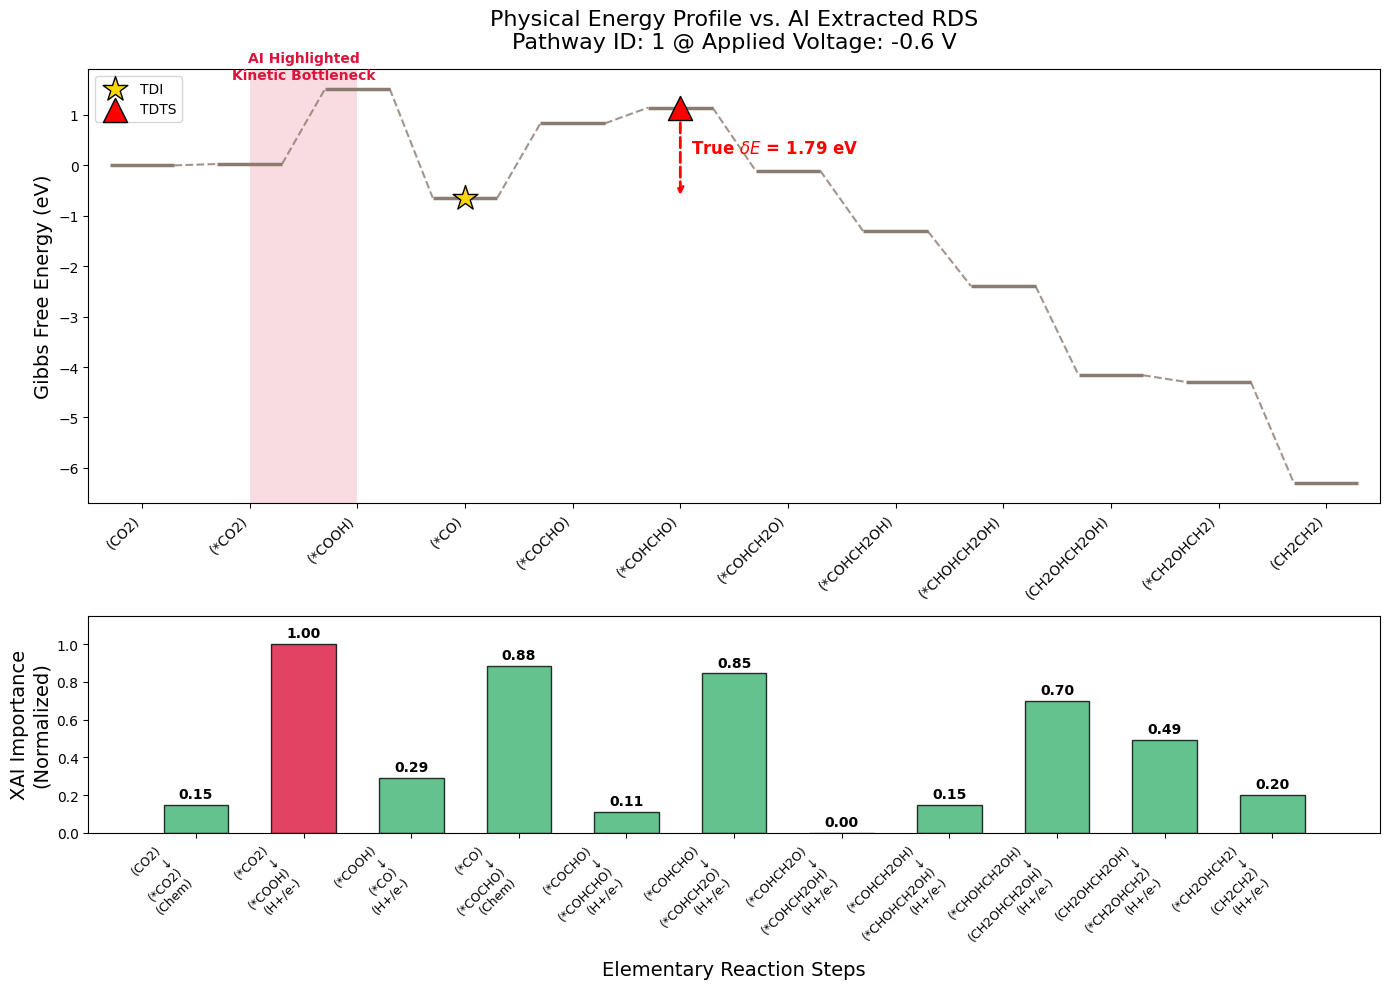

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.nn import GINEConv, global_max_pool
from torch_geometric.explain import Explainer, GNNExplainer

# ==========================================
# 1. 模型与数据集基座 (半经验架构)
# ==========================================
class CO2RR_GNN(nn.Module):
    def __init__(self, node_dim=1, edge_dim=2, hidden_dim=128):
        super(CO2RR_GNN, self).__init__()
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.edge_emb = nn.Linear(edge_dim, hidden_dim)
        nn1 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(nn1, edge_dim=hidden_dim)
        nn2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv2 = GINEConv(nn2, edge_dim=hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x, edge_index, edge_attr=None, batch=None, u=None):
        if batch is None: batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        if u is None: u = torch.zeros((1, 1), dtype=torch.float, device=x.device)
        u = u.view(-1, 1)

        if edge_attr is not None:
            dG_0 = edge_attr[:, 0].unsqueeze(1)
            is_pcet = edge_attr[:, 1].unsqueeze(1)
            u_expanded = u[batch[edge_index[0]]] 
            dG_U = dG_0 + is_pcet * u_expanded
            edge_attr_emb = self.edge_emb(torch.cat([dG_U, is_pcet], dim=1))
        else:
            edge_attr_emb = None

        x = self.node_emb(x)
        x = torch.relu(self.conv1(x, edge_index, edge_attr=edge_attr_emb))
        x = torch.relu(self.conv2(x, edge_index, edge_attr=edge_attr_emb))
        return self.mlp(global_max_pool(x, batch))

class CO2RREnergeticSpanDataset(InMemoryDataset):
    def __init__(self, csv_file, root='.', transform=None, pre_transform=None):
        self.csv_file = csv_file
        super().__init__(root, transform, pre_transform)
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.csv_file)
        data_list = []
        for _, row in df.iterrows():
            y = torch.tensor([row['Target_Energetic_Span_eV']], dtype=torch.float)
            u = torch.tensor([row['Voltage_V']], dtype=torch.float)
            path_id = torch.tensor([row['Path_Index']], dtype=torch.long)
            
            dg0_list = [float(x) for x in str(row['Base_dG_List']).split('|')]
            is_pcet_list = [float(x) for x in str(row['Is_PCET_List']).split('|')]
            num_edges = len(dg0_list)
            num_nodes = num_edges + 1
            
            edge_attr = torch.tensor(list(zip(dg0_list, is_pcet_list)), dtype=torch.float)
            edge_index = torch.tensor([list(range(num_nodes - 1)), list(range(1, num_nodes))], dtype=torch.long)
            x = torch.arange(num_nodes, dtype=torch.float).view(-1, 1)
            
            step_labels = []
            nodes_str = [s.strip() for s in str(row['Pathway_Topology']).split('->')]
            for i in range(num_edges):
                pcet_str = "(H+/e-)" if is_pcet_list[i] == 1.0 else "(Chem)"
                step_labels.append(f"{nodes_str[i]}\n↓\n{nodes_str[i+1]}\n{pcet_str}")

            data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, u=u, path_id=path_id)
            data.step_labels = step_labels
            data.nodes_str = nodes_str
            data_list.append(data)
        self.data, self.slices = self.collate(data_list)

# ==========================================
# 2. 物理与 AI 双面对齐印证模块 (标准台阶图 + 锁死随机种子)
# ==========================================
def calculate_true_energetic_span(dG_U_list):
    """严谨的物理计算：计算全局 TDI 和 TDTS，返回每一站的相对自由能 G 和跨度信息"""
    G_states = [0.0]
    for dg in dG_U_list:
        G_states.append(G_states[-1] + dg)
        
    max_span = -float('inf')
    tdi_idx, tdts_idx = 0, 0
    
    for i in range(len(G_states)):
        for j in range(i, len(G_states)):
            span = G_states[j] - G_states[i]
            if span > max_span:
                max_span = span
                tdi_idx = i
                tdts_idx = j
                
    return G_states, max_span, tdi_idx, tdts_idx

def plot_physics_vs_xai(model_path, csv_file, target_path_index=1, test_voltage=-1.0):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. 加载模型与数据
    model = CO2RR_GNN().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    dataset = CO2RREnergeticSpanDataset(csv_file=csv_file)
    data = next(d for d in dataset if d.path_id.item() == target_path_index).to(device)
    
    # 2. 计算动态物理特征
    u_tensor = torch.tensor([[test_voltage]], dtype=torch.float).to(device)
    dG_0_list = data.edge_attr[:, 0].cpu().numpy()
    is_pcet_list = data.edge_attr[:, 1].cpu().numpy()
    dG_U_list = dG_0_list + is_pcet_list * test_voltage
    
    G_states, true_span, tdi_idx, tdts_idx = calculate_true_energetic_span(dG_U_list)
    
    # 保证 GNNExplainer 每次初始化的 mask 和梯度下降轨迹完全一致
    torch.manual_seed(42)
    np.random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
    
    # 3. 运行 GNNExplainer
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=300, lr=0.005),
        explanation_type='model',
        edge_mask_type='object',
        model_config=dict(mode='regression', task_level='graph', return_type='raw')
    )
    explanation = explainer(x=data.x, edge_index=data.edge_index, edge_attr=data.edge_attr, u=u_tensor)
    xai_weights = explanation.edge_mask.cpu().numpy()
    xai_weights_norm = xai_weights / xai_weights.max() 
    
    # 4. 双面对齐可视化绘制
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False, gridspec_kw={'height_ratios': [2, 1]})
    
    num_steps = len(dG_U_list)
    x_nodes = np.arange(num_steps + 1)
    x_edges = np.arange(num_steps) + 0.5 
    
    # ==========================================
    # --- 图 A: 真实的物理自由能台阶图 (Step Diagram) ---
    # ==========================================
    step_width = 0.6  # 平台宽度
    hw = step_width / 2.0
    line_color = '#8b7a70' # 经典的高级灰褐色
    
    for i in range(num_steps + 1):
        # 1. 画水平平台 (代表稳态中间体)
        ax1.hlines(y=G_states[i], xmin=i - hw, xmax=i + hw, color=line_color, lw=2.5, zorder=3)
        
        # 2. 画虚线连接 (代表反应过程/过渡态趋势)
        if i < num_steps:
            ax1.plot([i + hw, i + 1 - hw], [G_states[i], G_states[i+1]], 
                     color=line_color, ls='--', lw=1.5, alpha=0.8, zorder=2)

    # 标注 TDI 和 TDTS (放在水平平台的正中央)
    ax1.scatter(tdi_idx, G_states[tdi_idx], s=350, marker='*', color='gold', zorder=6, edgecolor='k', label='TDI')
    ax1.scatter(tdts_idx, G_states[tdts_idx], s=300, marker='^', color='red', zorder=6, edgecolor='k', label='TDTS')
    
    # 画全局能量跨度的指示箭头
    if tdts_idx > tdi_idx:
        ax1.annotate('', xy=(tdts_idx, G_states[tdts_idx]), xytext=(tdts_idx, G_states[tdi_idx]),
                     arrowprops=dict(arrowstyle="<->", color="red", lw=2, ls='--'))
        ax1.text(tdts_idx + 0.1, (G_states[tdi_idx] + G_states[tdts_idx])/2, f'True $\delta E$ = {true_span:.2f} eV', color='red', fontsize=12, fontweight='bold')
    
    ax1.set_ylabel('Gibbs Free Energy (eV)', fontsize=14)
    ax1.set_title(f'Physical Energy Profile vs. AI Extracted RDS\nPathway ID: {target_path_index} @ Applied Voltage: {test_voltage} V', fontsize=16, pad=15)
    ax1.set_xticks(x_nodes)
    ax1.set_xticklabels(data.nodes_str, rotation=45, ha='right', fontsize=10)
    ax1.legend(loc='upper left')
    
    # ==========================================
    # --- 图 B: AI (GNNExplainer) 提取的局部动力学阻力权重 ---
    # ==========================================
    bars = ax2.bar(x_edges, xai_weights_norm, color='mediumseagreen', width=0.6, edgecolor='k', alpha=0.8)
    
    ai_top_step = np.argmax(xai_weights_norm)
    bars[ai_top_step].set_color('crimson')
    bars[ai_top_step].set_edgecolor('k')
    
    # 🌟 新增功能：在柱子上标出具体的权重数值
    for bar in bars:
        yval = bar.get_height()
        # 将数值标注在柱子顶部上方，保留两位小数
        ax2.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.02, 
                 f'{yval:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 稍微拉高 Y 轴上限，防止最高的 1.00 被边框切掉
    ax2.set_ylim(0, 1.15)
    
    # 完美对齐的红色高亮背景带 (跨越两端平台，对应整条连接边)
    rect = patches.Rectangle((ai_top_step, ax1.get_ylim()[0]), 1, ax1.get_ylim()[1] - ax1.get_ylim()[0], 
                             linewidth=0, facecolor='crimson', alpha=0.15, zorder=0)
    ax1.add_patch(rect)
    ax1.text(ai_top_step + 0.5, ax1.get_ylim()[1]*0.9, 'AI Highlighted\nKinetic Bottleneck', ha='center', color='crimson', fontsize=10, fontweight='bold')

    ax2.set_ylabel('XAI Importance\n(Normalized)', fontsize=14)
    ax2.set_xlabel('Elementary Reaction Steps', fontsize=14)
    ax2.set_xticks(x_edges)
    ax2.set_xticklabels(data.step_labels, rotation=45, ha='right', fontsize=9)
    ax2.set_xlim(-0.5, num_steps + 0.5)
    ax1.set_xlim(-0.5, num_steps + 0.5)
    
    plt.tight_layout()
    plot_filename = f'step_profile_vs_xai_path_{target_path_index}_at_{test_voltage}V.png'
    plt.savefig(plot_filename, dpi=300)
    print(f"\n🎉 台阶图双面对齐图表（含数值标注）生成完毕！已保存至：【{plot_filename}】")


if __name__ == "__main__":
    CSV_FILE_NAME = 'ML_Dataset_CH2CH2_Voltage_Scanned.csv'
    MODEL_WEIGHTS = 'best_semi_empirical_model.pth' 
    
    try:
        plot_physics_vs_xai(MODEL_WEIGHTS, CSV_FILE_NAME, target_path_index=1, test_voltage=-0.6)
    except FileNotFoundError:
        print(f"❌ 找不到模型权重或数据集，请检查目录。")
    except Exception as e:
        print(f"❌ 运行报错：{str(e)}")

# *COCO

🔍 正在寻找包含 '*COCO' 且在 -0.6 V 下能量跨度最低的最优路径...
🎯 锁定最优路径 ID: 46，该路径在 -0.6 V 下的真实能量跨度为: 1.5190 eV
💾 绘图原始数据已成功提取并保存至：【optimal_pathway_46_at_-0.6V_data.csv】
🎉 最优路径台阶图生成完毕！已保存至：【optimal_pathway_46_at_-0.6V.png】


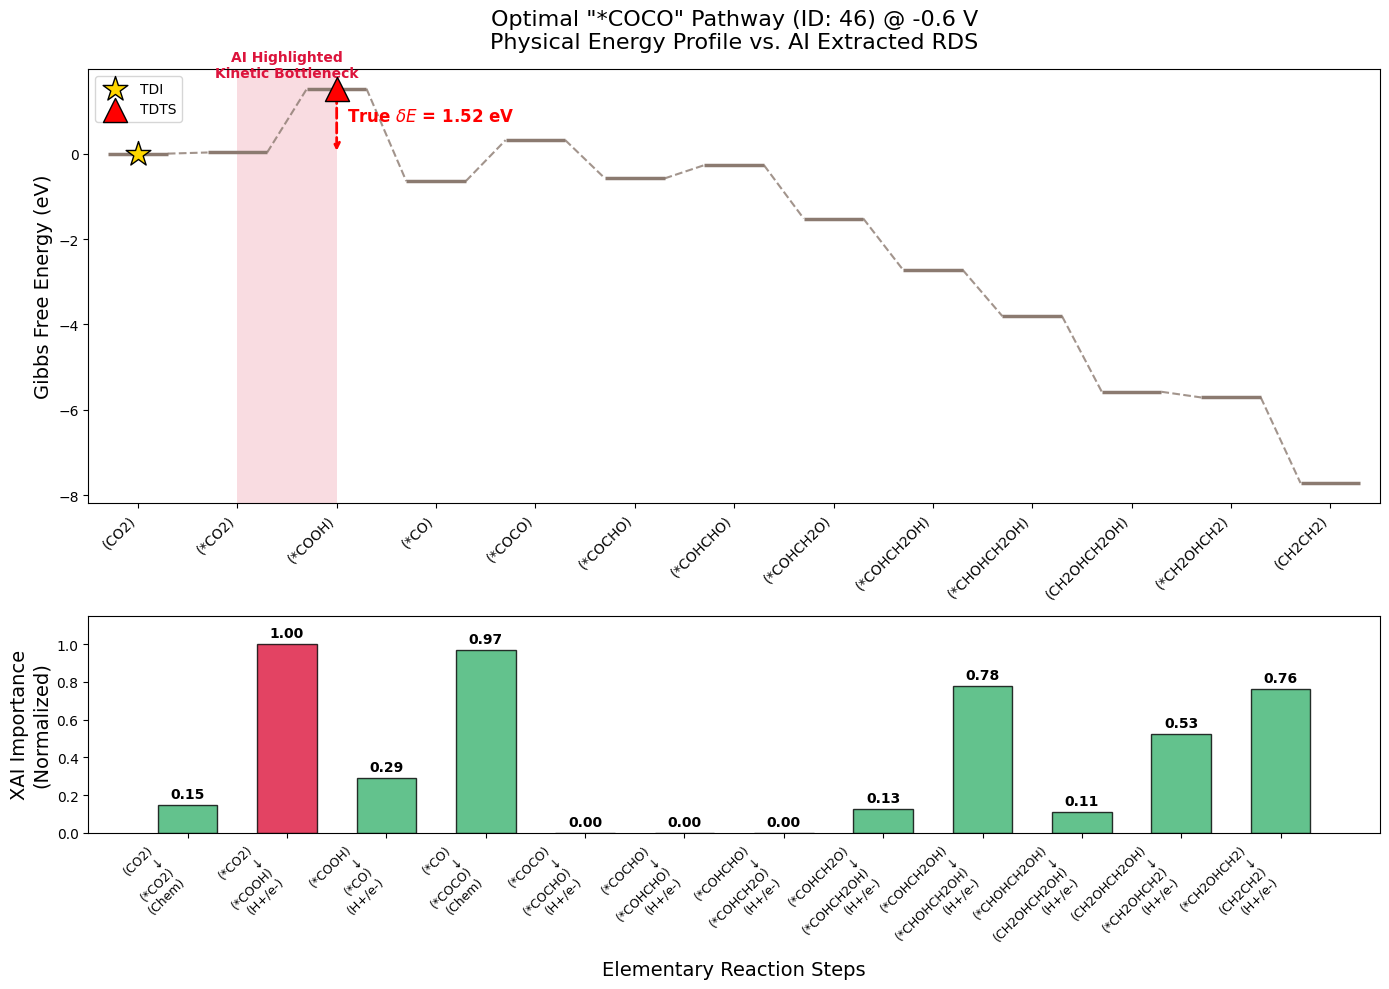

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.nn import GINEConv, global_max_pool
from torch_geometric.explain import Explainer, GNNExplainer

# ==========================================
# 1. 模型与数据集基座 (半经验架构)
# ==========================================
class CO2RR_GNN(nn.Module):
    def __init__(self, node_dim=1, edge_dim=2, hidden_dim=128):
        super(CO2RR_GNN, self).__init__()
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.edge_emb = nn.Linear(edge_dim, hidden_dim)
        nn1 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(nn1, edge_dim=hidden_dim)
        nn2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv2 = GINEConv(nn2, edge_dim=hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x, edge_index, edge_attr=None, batch=None, u=None):
        if batch is None: batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        if u is None: u = torch.zeros((1, 1), dtype=torch.float, device=x.device)
        u = u.view(-1, 1)

        if edge_attr is not None:
            dG_0 = edge_attr[:, 0].unsqueeze(1)
            is_pcet = edge_attr[:, 1].unsqueeze(1)
            u_expanded = u[batch[edge_index[0]]] 
            dG_U = dG_0 + is_pcet * u_expanded
            edge_attr_emb = self.edge_emb(torch.cat([dG_U, is_pcet], dim=1))
        else:
            edge_attr_emb = None

        x = self.node_emb(x)
        x = torch.relu(self.conv1(x, edge_index, edge_attr=edge_attr_emb))
        x = torch.relu(self.conv2(x, edge_index, edge_attr=edge_attr_emb))
        return self.mlp(global_max_pool(x, batch))

class CO2RREnergeticSpanDataset(InMemoryDataset):
    def __init__(self, csv_file, root='.', transform=None, pre_transform=None):
        self.csv_file = csv_file
        super().__init__(root, transform, pre_transform)
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.csv_file)
        data_list = []
        for _, row in df.iterrows():
            y = torch.tensor([row['Target_Energetic_Span_eV']], dtype=torch.float)
            u = torch.tensor([row['Voltage_V']], dtype=torch.float)
            path_id = torch.tensor([row['Path_Index']], dtype=torch.long)
            
            dg0_list = [float(x) for x in str(row['Base_dG_List']).split('|')]
            is_pcet_list = [float(x) for x in str(row['Is_PCET_List']).split('|')]
            num_edges = len(dg0_list)
            num_nodes = num_edges + 1
            
            edge_attr = torch.tensor(list(zip(dg0_list, is_pcet_list)), dtype=torch.float)
            edge_index = torch.tensor([list(range(num_nodes - 1)), list(range(1, num_nodes))], dtype=torch.long)
            x = torch.arange(num_nodes, dtype=torch.float).view(-1, 1)
            
            step_labels = []
            nodes_str = [s.strip() for s in str(row['Pathway_Topology']).split('->')]
            for i in range(num_edges):
                pcet_str = "(H+/e-)" if is_pcet_list[i] == 1.0 else "(Chem)"
                step_labels.append(f"{nodes_str[i]}\n↓\n{nodes_str[i+1]}\n{pcet_str}")

            data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, u=u, path_id=path_id)
            data.step_labels = step_labels
            data.nodes_str = nodes_str
            data_list.append(data)
        self.data, self.slices = self.collate(data_list)

# ==========================================
# 2. 物理跨度计算与智能寻优模块
# ==========================================
def calculate_true_energetic_span(dG_U_list):
    G_states = [0.0]
    for dg in dG_U_list:
        G_states.append(G_states[-1] + dg)
        
    max_span = -float('inf')
    tdi_idx, tdts_idx = 0, 0
    
    for i in range(len(G_states)):
        for j in range(i, len(G_states)):
            span = G_states[j] - G_states[i]
            if span > max_span:
                max_span = span
                tdi_idx = i
                tdts_idx = j
                
    return G_states, max_span, tdi_idx, tdts_idx

def find_optimal_pathway(csv_file, target_keyword, test_voltage):
    df = pd.read_csv(csv_file)
    filtered_df = df[df['Pathway_Topology'].astype(str).str.contains(target_keyword, regex=False, na=False)]
    unique_path_ids = filtered_df['Path_Index'].unique()
    
    if len(unique_path_ids) == 0: return None, None
        
    min_span = float('inf')
    optimal_path_id = -1
    
    for pid in unique_path_ids:
        row = filtered_df[filtered_df['Path_Index'] == pid].iloc[0]
        dg0_list = np.array([float(x) for x in str(row['Base_dG_List']).split('|')])
        is_pcet_list = np.array([float(x) for x in str(row['Is_PCET_List']).split('|')])
        
        dG_U_list = dg0_list + is_pcet_list * test_voltage
        _, span, _, _ = calculate_true_energetic_span(dG_U_list)
        
        if span < min_span:
            min_span = span
            optimal_path_id = pid
            
    return optimal_path_id, min_span

# ==========================================
# 3. 物理与 AI 双面对齐绘图并导出数据模块
# ==========================================
def plot_physics_vs_xai(model_path, csv_file, target_path_index, test_voltage):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model = CO2RR_GNN().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    dataset = CO2RREnergeticSpanDataset(csv_file=csv_file)
    data = next(d for d in dataset if d.path_id.item() == target_path_index).to(device)
    
    u_tensor = torch.tensor([[test_voltage]], dtype=torch.float).to(device)
    dG_0_list = data.edge_attr[:, 0].cpu().numpy()
    is_pcet_list = data.edge_attr[:, 1].cpu().numpy()
    dG_U_list = dG_0_list + is_pcet_list * test_voltage
    
    G_states, true_span, tdi_idx, tdts_idx = calculate_true_energetic_span(dG_U_list)
    
    # 锁死随机种子，保证结果一致性
    torch.manual_seed(42)
    np.random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
    
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=300, lr=0.005),
        explanation_type='model',
        edge_mask_type='object',
        model_config=dict(mode='regression', task_level='graph', return_type='raw')
    )
    explanation = explainer(x=data.x, edge_index=data.edge_index, edge_attr=data.edge_attr, u=u_tensor)
    xai_weights = explanation.edge_mask.cpu().numpy()
    xai_weights_norm = xai_weights / xai_weights.max() 
    
    # ==========================================
    # 🌟 核心新增：将画图数据打包保存至 CSV 🌟
    # ==========================================
    num_steps = len(dG_U_list)
    step_indices = list(range(num_steps + 1))
    
    # 节点数量比边数量多 1，为了对齐 DataFrame，给边的列表末尾补 None
    reaction_steps_clean = [label.replace('\n', ' ') for label in data.step_labels] + ["End_of_Pathway"]
    xai_imp_padded = list(xai_weights_norm) + [None]
    dG_U_padded = list(dG_U_list) + [None]
    
    is_tdi = [True if i == tdi_idx else False for i in step_indices]
    is_tdts = [True if i == tdts_idx else False for i in step_indices]

    export_df = pd.DataFrame({
        'Node_Index': step_indices,
        'Intermediate_State': data.nodes_str,
        'Relative_Free_Energy_G_eV': G_states,
        'Is_TDI_Valley': is_tdi,
        'Is_TDTS_Peak': is_tdts,
        'Forward_Elementary_Step': reaction_steps_clean,
        'Step_dG_U_eV': dG_U_padded,
        'AI_Extracted_Importance': xai_imp_padded
    })
    
    csv_filename = f'optimal_pathway_{target_path_index}_at_{test_voltage}V_data.csv'
    export_df.to_csv(csv_filename, index=False)
    print(f"💾 绘图原始数据已成功提取并保存至：【{csv_filename}】")
    
    # ==========================================
    # 绘图部分 (保持不变)
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False, gridspec_kw={'height_ratios': [2, 1]})
    
    x_nodes = np.arange(num_steps + 1)
    x_edges = np.arange(num_steps) + 0.5 
    
    step_width = 0.6
    hw = step_width / 2.0
    line_color = '#8b7a70'
    
    for i in range(num_steps + 1):
        ax1.hlines(y=G_states[i], xmin=i - hw, xmax=i + hw, color=line_color, lw=2.5, zorder=3)
        if i < num_steps:
            ax1.plot([i + hw, i + 1 - hw], [G_states[i], G_states[i+1]], 
                     color=line_color, ls='--', lw=1.5, alpha=0.8, zorder=2)

    ax1.scatter(tdi_idx, G_states[tdi_idx], s=350, marker='*', color='gold', zorder=6, edgecolor='k', label='TDI')
    ax1.scatter(tdts_idx, G_states[tdts_idx], s=300, marker='^', color='red', zorder=6, edgecolor='k', label='TDTS')
    
    if tdts_idx > tdi_idx:
        ax1.annotate('', xy=(tdts_idx, G_states[tdts_idx]), xytext=(tdts_idx, G_states[tdi_idx]),
                     arrowprops=dict(arrowstyle="<->", color="red", lw=2, ls='--'))
        ax1.text(tdts_idx + 0.1, (G_states[tdi_idx] + G_states[tdts_idx])/2, f'True $\delta E$ = {true_span:.2f} eV', color='red', fontsize=12, fontweight='bold')
    
    ax1.set_ylabel('Gibbs Free Energy (eV)', fontsize=14)
    ax1.set_title(f'Optimal "{TARGET_KEYWORD}" Pathway (ID: {target_path_index}) @ {test_voltage} V\nPhysical Energy Profile vs. AI Extracted RDS', fontsize=16, pad=15)
    ax1.set_xticks(x_nodes)
    ax1.set_xticklabels(data.nodes_str, rotation=45, ha='right', fontsize=10)
    ax1.legend(loc='upper left')
    
    bars = ax2.bar(x_edges, xai_weights_norm, color='mediumseagreen', width=0.6, edgecolor='k', alpha=0.8)
    ai_top_step = np.argmax(xai_weights_norm)
    bars[ai_top_step].set_color('crimson')
    bars[ai_top_step].set_edgecolor('k')
    
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.02, 
                 f'{yval:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_ylim(0, 1.15)
    
    rect = patches.Rectangle((ai_top_step, ax1.get_ylim()[0]), 1, ax1.get_ylim()[1] - ax1.get_ylim()[0], 
                             linewidth=0, facecolor='crimson', alpha=0.15, zorder=0)
    ax1.add_patch(rect)
    ax1.text(ai_top_step + 0.5, ax1.get_ylim()[1]*0.9, 'AI Highlighted\nKinetic Bottleneck', ha='center', color='crimson', fontsize=10, fontweight='bold')

    ax2.set_ylabel('XAI Importance\n(Normalized)', fontsize=14)
    ax2.set_xlabel('Elementary Reaction Steps', fontsize=14)
    ax2.set_xticks(x_edges)
    ax2.set_xticklabels(data.step_labels, rotation=45, ha='right', fontsize=9)
    ax2.set_xlim(-0.5, num_steps + 0.5)
    ax1.set_xlim(-0.5, num_steps + 0.5)
    
    plt.tight_layout()
    plot_filename = f'optimal_pathway_{target_path_index}_at_{test_voltage}V.png'
    plt.savefig(plot_filename, dpi=300)
    print(f"🎉 最优路径台阶图生成完毕！已保存至：【{plot_filename}】")


# ==========================================
# 4. 主程序入口
# ==========================================
if __name__ == "__main__":
    CSV_FILE_NAME = 'ML_Dataset_CH2CH2_Voltage_Scanned.csv'
    MODEL_WEIGHTS = 'best_semi_empirical_model.pth' 
    
    TARGET_KEYWORD = "*COCO"
    TEST_VOLTAGE = -0.6
    
    try:
        print(f"🔍 正在寻找包含 '{TARGET_KEYWORD}' 且在 {TEST_VOLTAGE} V 下能量跨度最低的最优路径...")
        optimal_pid, min_span = find_optimal_pathway(CSV_FILE_NAME, TARGET_KEYWORD, TEST_VOLTAGE)
        
        if optimal_pid is not None:
            print(f"🎯 锁定最优路径 ID: {optimal_pid}，该路径在 {TEST_VOLTAGE} V 下的真实能量跨度为: {min_span:.4f} eV")
            plot_physics_vs_xai(MODEL_WEIGHTS, CSV_FILE_NAME, target_path_index=optimal_pid, test_voltage=TEST_VOLTAGE)
        else:
            print(f"⚠️ 未找到包含 '{TARGET_KEYWORD}' 的路径，请检查数据集或关键字拼写。")
            
    except FileNotFoundError:
        print(f"❌ 找不到模型权重或数据集，请检查目录。")
    except Exception as e:
        print(f"❌ 运行报错：{str(e)}")

🔍 正在寻找包含 '*COHCHO' 且在 -0.6 V 下能量跨度最低的最优路径...
🎯 锁定最优路径 ID: 2，该路径在 -0.6 V 下的真实能量跨度为: 1.5190 eV
💾 绘图原始数据已成功提取并保存至：【output_results\optimal_pathway_2_at_-0.6V_data.csv】
🎉 最优路径台阶图生成完毕！已保存至：【output_results\optimal_pathway_2_at_-0.6V.png】


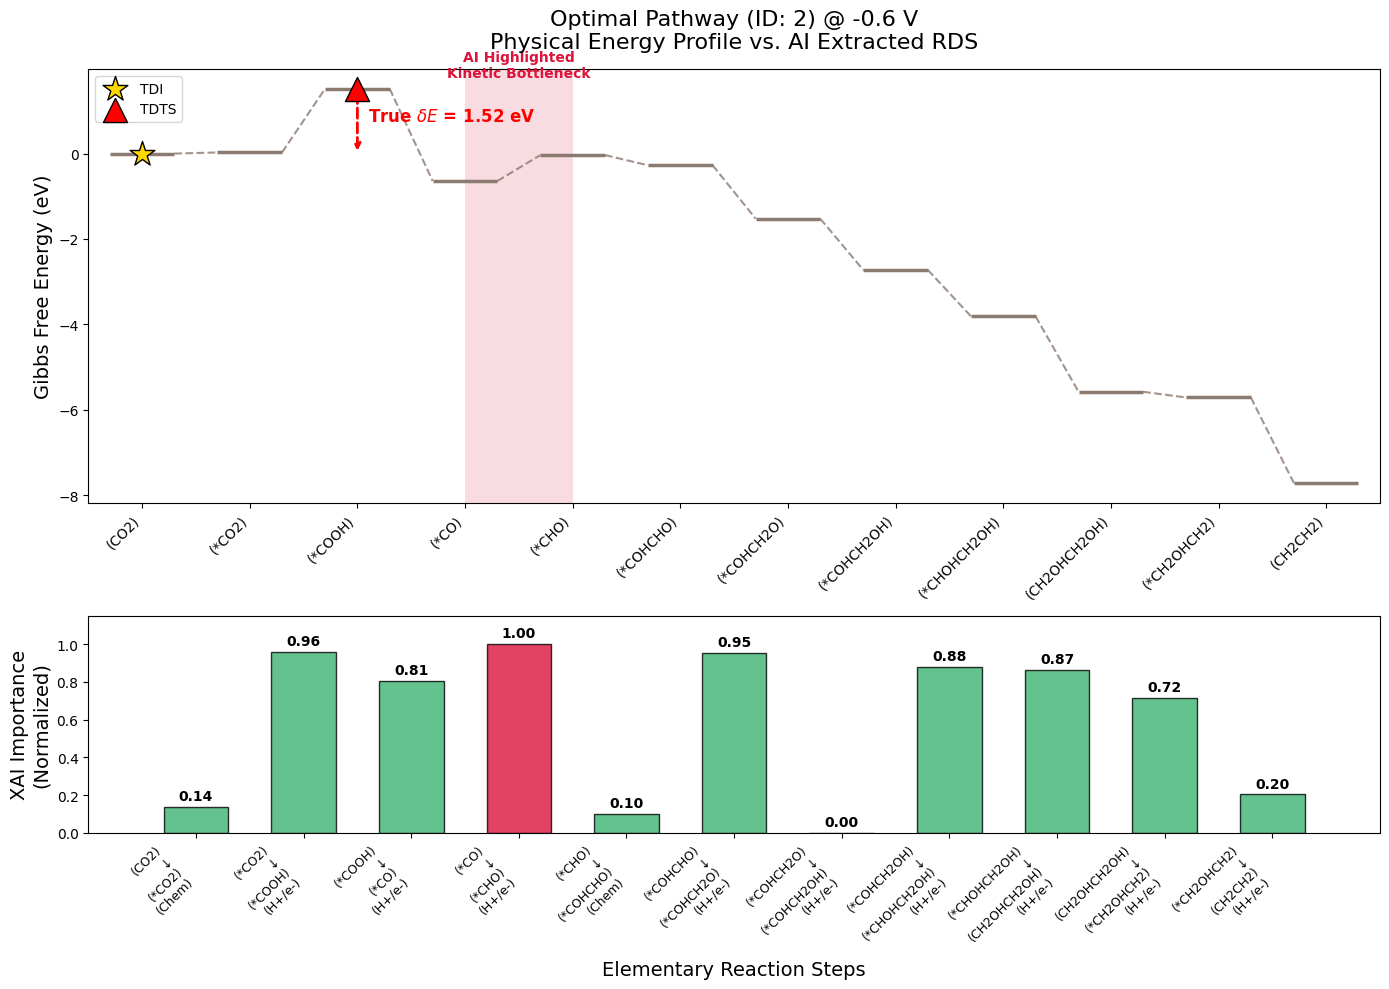

In [3]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.nn import GINEConv, global_max_pool
from torch_geometric.explain import Explainer, GNNExplainer

# ==========================================
# 1. 模型与数据集基座 (半经验架构)
# ==========================================
class CO2RR_GNN(nn.Module):
    def __init__(self, node_dim=1, edge_dim=2, hidden_dim=128):
        super(CO2RR_GNN, self).__init__()
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.edge_emb = nn.Linear(edge_dim, hidden_dim)
        nn1 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(nn1, edge_dim=hidden_dim)
        nn2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv2 = GINEConv(nn2, edge_dim=hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x, edge_index, edge_attr=None, batch=None, u=None):
        if batch is None: batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        if u is None: u = torch.zeros((1, 1), dtype=torch.float, device=x.device)
        u = u.view(-1, 1)

        if edge_attr is not None:
            dG_0 = edge_attr[:, 0].unsqueeze(1)
            is_pcet = edge_attr[:, 1].unsqueeze(1)
            u_expanded = u[batch[edge_index[0]]] 
            dG_U = dG_0 + is_pcet * u_expanded
            edge_attr_emb = self.edge_emb(torch.cat([dG_U, is_pcet], dim=1))
        else:
            edge_attr_emb = None

        x = self.node_emb(x)
        x = torch.relu(self.conv1(x, edge_index, edge_attr=edge_attr_emb))
        x = torch.relu(self.conv2(x, edge_index, edge_attr=edge_attr_emb))
        return self.mlp(global_max_pool(x, batch))

class CO2RREnergeticSpanDataset(InMemoryDataset):
    def __init__(self, csv_file, root='.', transform=None, pre_transform=None):
        self.csv_file = csv_file
        super().__init__(root, transform, pre_transform)
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.csv_file)
        data_list = []
        for _, row in df.iterrows():
            y = torch.tensor([row['Target_Energetic_Span_eV']], dtype=torch.float)
            u = torch.tensor([row['Voltage_V']], dtype=torch.float)
            path_id = torch.tensor([row['Path_Index']], dtype=torch.long)
            
            dg0_list = [float(x) for x in str(row['Base_dG_List']).split('|')]
            is_pcet_list = [float(x) for x in str(row['Is_PCET_List']).split('|')]
            num_edges = len(dg0_list)
            num_nodes = num_edges + 1
            
            edge_attr = torch.tensor(list(zip(dg0_list, is_pcet_list)), dtype=torch.float)
            edge_index = torch.tensor([list(range(num_nodes - 1)), list(range(1, num_nodes))], dtype=torch.long)
            x = torch.arange(num_nodes, dtype=torch.float).view(-1, 1)
            
            step_labels = []
            nodes_str = [s.strip() for s in str(row['Pathway_Topology']).split('->')]
            for i in range(num_edges):
                pcet_str = "(H+/e-)" if is_pcet_list[i] == 1.0 else "(Chem)"
                step_labels.append(f"{nodes_str[i]}\n↓\n{nodes_str[i+1]}\n{pcet_str}")

            data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, u=u, path_id=path_id)
            data.step_labels = step_labels
            data.nodes_str = nodes_str
            data_list.append(data)
        self.data, self.slices = self.collate(data_list)

# ==========================================
# 2. 物理跨度计算与智能寻优模块
# ==========================================
def calculate_true_energetic_span(dG_U_list):
    G_states = [0.0]
    for dg in dG_U_list:
        G_states.append(G_states[-1] + dg)
        
    max_span = -float('inf')
    tdi_idx, tdts_idx = 0, 0
    
    for i in range(len(G_states)):
        for j in range(i, len(G_states)):
            span = G_states[j] - G_states[i]
            if span > max_span:
                max_span = span
                tdi_idx = i
                tdts_idx = j
                
    return G_states, max_span, tdi_idx, tdts_idx

def find_optimal_pathway(csv_file, target_keyword, test_voltage):
    df = pd.read_csv(csv_file)
    filtered_df = df[df['Pathway_Topology'].astype(str).str.contains(target_keyword, regex=False, na=False)]
    unique_path_ids = filtered_df['Path_Index'].unique()
    
    if len(unique_path_ids) == 0: return None, None
        
    min_span = float('inf')
    optimal_path_id = -1
    
    for pid in unique_path_ids:
        row = filtered_df[filtered_df['Path_Index'] == pid].iloc[0]
        dg0_list = np.array([float(x) for x in str(row['Base_dG_List']).split('|')])
        is_pcet_list = np.array([float(x) for x in str(row['Is_PCET_List']).split('|')])
        
        dG_U_list = dg0_list + is_pcet_list * test_voltage
        _, span, _, _ = calculate_true_energetic_span(dG_U_list)
        
        if span < min_span:
            min_span = span
            optimal_path_id = pid
            
    return optimal_path_id, min_span

# ==========================================
# 3. 物理与 AI 双面对齐绘图并导出数据模块
# ==========================================
def plot_physics_vs_xai(model_path, csv_file, target_path_index, test_voltage, output_dir):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model = CO2RR_GNN().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    dataset = CO2RREnergeticSpanDataset(csv_file=csv_file)
    data = next(d for d in dataset if d.path_id.item() == target_path_index).to(device)
    
    u_tensor = torch.tensor([[test_voltage]], dtype=torch.float).to(device)
    dG_0_list = data.edge_attr[:, 0].cpu().numpy()
    is_pcet_list = data.edge_attr[:, 1].cpu().numpy()
    dG_U_list = dG_0_list + is_pcet_list * test_voltage
    
    G_states, true_span, tdi_idx, tdts_idx = calculate_true_energetic_span(dG_U_list)
    
    # 锁死随机种子，保证结果一致性
    torch.manual_seed(42)
    np.random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
    
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=300, lr=0.005),
        explanation_type='model',
        edge_mask_type='object',
        model_config=dict(mode='regression', task_level='graph', return_type='raw')
    )
    explanation = explainer(x=data.x, edge_index=data.edge_index, edge_attr=data.edge_attr, u=u_tensor)
    xai_weights = explanation.edge_mask.cpu().numpy()
    xai_weights_norm = xai_weights / xai_weights.max() 
    
    # ==========================================
    # 提取画图数据打包保存至 CSV 
    # ==========================================
    num_steps = len(dG_U_list)
    step_indices = list(range(num_steps + 1))
    
    reaction_steps_clean = [label.replace('\n', ' ') for label in data.step_labels] + ["End_of_Pathway"]
    xai_imp_padded = list(xai_weights_norm) + [None]
    dG_U_padded = list(dG_U_list) + [None]
    
    is_tdi = [True if i == tdi_idx else False for i in step_indices]
    is_tdts = [True if i == tdts_idx else False for i in step_indices]

    export_df = pd.DataFrame({
        'Node_Index': step_indices,
        'Intermediate_State': data.nodes_str,
        'Relative_Free_Energy_G_eV': G_states,
        'Is_TDI_Valley': is_tdi,
        'Is_TDTS_Peak': is_tdts,
        'Forward_Elementary_Step': reaction_steps_clean,
        'Step_dG_U_eV': dG_U_padded,
        'AI_Extracted_Importance': xai_imp_padded
    })
    
    # 设置 CSV 保存路径
    csv_filename = os.path.join(output_dir, f'optimal_pathway_{target_path_index}_at_{test_voltage}V_data.csv')
    export_df.to_csv(csv_filename, index=False)
    print(f"💾 绘图原始数据已成功提取并保存至：【{csv_filename}】")
    
    # ==========================================
    # 绘图部分 
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False, gridspec_kw={'height_ratios': [2, 1]})
    
    x_nodes = np.arange(num_steps + 1)
    x_edges = np.arange(num_steps) + 0.5 
    
    step_width = 0.6
    hw = step_width / 2.0
    line_color = '#8b7a70'
    
    for i in range(num_steps + 1):
        ax1.hlines(y=G_states[i], xmin=i - hw, xmax=i + hw, color=line_color, lw=2.5, zorder=3)
        if i < num_steps:
            ax1.plot([i + hw, i + 1 - hw], [G_states[i], G_states[i+1]], 
                     color=line_color, ls='--', lw=1.5, alpha=0.8, zorder=2)

    ax1.scatter(tdi_idx, G_states[tdi_idx], s=350, marker='*', color='gold', zorder=6, edgecolor='k', label='TDI')
    ax1.scatter(tdts_idx, G_states[tdts_idx], s=300, marker='^', color='red', zorder=6, edgecolor='k', label='TDTS')
    
    if tdts_idx > tdi_idx:
        ax1.annotate('', xy=(tdts_idx, G_states[tdts_idx]), xytext=(tdts_idx, G_states[tdi_idx]),
                     arrowprops=dict(arrowstyle="<->", color="red", lw=2, ls='--'))
        ax1.text(tdts_idx + 0.1, (G_states[tdi_idx] + G_states[tdts_idx])/2, f'True $\delta E$ = {true_span:.2f} eV', color='red', fontsize=12, fontweight='bold')
    
    ax1.set_ylabel('Gibbs Free Energy (eV)', fontsize=14)
    ax1.set_title(f'Optimal Pathway (ID: {target_path_index}) @ {test_voltage} V\nPhysical Energy Profile vs. AI Extracted RDS', fontsize=16, pad=15)
    ax1.set_xticks(x_nodes)
    ax1.set_xticklabels(data.nodes_str, rotation=45, ha='right', fontsize=10)
    ax1.legend(loc='upper left')
    
    bars = ax2.bar(x_edges, xai_weights_norm, color='mediumseagreen', width=0.6, edgecolor='k', alpha=0.8)
    ai_top_step = np.argmax(xai_weights_norm)
    bars[ai_top_step].set_color('crimson')
    bars[ai_top_step].set_edgecolor('k')
    
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.02, 
                 f'{yval:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_ylim(0, 1.15)
    
    rect = patches.Rectangle((ai_top_step, ax1.get_ylim()[0]), 1, ax1.get_ylim()[1] - ax1.get_ylim()[0], 
                             linewidth=0, facecolor='crimson', alpha=0.15, zorder=0)
    ax1.add_patch(rect)
    ax1.text(ai_top_step + 0.5, ax1.get_ylim()[1]*0.9, 'AI Highlighted\nKinetic Bottleneck', ha='center', color='crimson', fontsize=10, fontweight='bold')

    ax2.set_ylabel('XAI Importance\n(Normalized)', fontsize=14)
    ax2.set_xlabel('Elementary Reaction Steps', fontsize=14)
    ax2.set_xticks(x_edges)
    ax2.set_xticklabels(data.step_labels, rotation=45, ha='right', fontsize=9)
    ax2.set_xlim(-0.5, num_steps + 0.5)
    ax1.set_xlim(-0.5, num_steps + 0.5)
    
    plt.tight_layout()
    
    # 设置 PNG 保存路径
    plot_filename = os.path.join(output_dir, f'optimal_pathway_{target_path_index}_at_{test_voltage}V.png')
    plt.savefig(plot_filename, dpi=300)
    print(f"🎉 最优路径台阶图生成完毕！已保存至：【{plot_filename}】")


# ==========================================
# 4. 主程序入口
# ==========================================
if __name__ == "__main__":
    CSV_FILE_NAME = 'ML_Dataset_CH2CH2_Voltage_Scanned.csv'
    MODEL_WEIGHTS = 'best_semi_empirical_model.pth' 
    
    TARGET_KEYWORD = "*COHCHO"
    TEST_VOLTAGE = -0.6
    
    # 新增：定义并创建输出文件夹
    OUTPUT_DIR = "output_results"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    try:
        print(f"🔍 正在寻找包含 '{TARGET_KEYWORD}' 且在 {TEST_VOLTAGE} V 下能量跨度最低的最优路径...")
        optimal_pid, min_span = find_optimal_pathway(CSV_FILE_NAME, TARGET_KEYWORD, TEST_VOLTAGE)
        
        if optimal_pid is not None:
            print(f"🎯 锁定最优路径 ID: {optimal_pid}，该路径在 {TEST_VOLTAGE} V 下的真实能量跨度为: {min_span:.4f} eV")
            plot_physics_vs_xai(MODEL_WEIGHTS, CSV_FILE_NAME, 
                                target_path_index=optimal_pid, 
                                test_voltage=TEST_VOLTAGE, 
                                output_dir=OUTPUT_DIR)
        else:
            print(f"⚠️ 未找到包含 '{TARGET_KEYWORD}' 的路径，请检查数据集或关键字拼写。")
            
    except FileNotFoundError:
        print(f"❌ 找不到模型权重或数据集，请检查目录中的 {CSV_FILE_NAME} 和 {MODEL_WEIGHTS} 是否存在。")
    except Exception as e:
        print(f"❌ 运行报错：{str(e)}")